# Prophet

# Setup

In [1]:
!pip install prophet mlflow --quiet
import pandas as pd, numpy as np, mlflow, os
import matplotlib.pyplot as plt
from prophet import Prophet
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
dagshub_token = user_secrets.get_secret("DAGSHUB_TOKEN")
os.environ['MLFLOW_TRACKING_USERNAME'] = 'gdzag22'
os.environ['MLFLOW_TRACKING_PASSWORD'] = dagshub_token
mlflow.set_tracking_uri("https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow")
mlflow.set_experiment("Prophet_Training")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 83.0 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 64.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.0/121.0 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.6/954.6 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.9/214.9 kB 12.9 MB/s eta 0:00:00


2026/07/11 22:46:46 INFO mlflow.tracking.fluent: Experiment with name 'Prophet_Training' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/954b7962fd7e408898bd1c5cc0374f35', creation_time=1783810006170, effective_trace_archival_retention=None, experiment_id='8', last_update_time=1783810006170, lifecycle_stage='active', name='Prophet_Training', tags={}, trace_location=None, workspace='default'>

# Shared functions (from EDA notebook)

In [2]:
def load_and_merge(df, features, stores):
    out = df.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
    out = out.merge(stores, on='Store', how='left')
    out['Date'] = pd.to_datetime(out['Date'])
    return out.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

MD_COLS = [f"MarkDown{i}" for i in range(1, 6)]

def preprocess(df):
    out = df.copy()
    out[MD_COLS] = out[MD_COLS].fillna(0)
    out[["CPI", "Unemployment"]] = out.groupby("Store")[["CPI", "Unemployment"]].ffill()
    return out

def wmae(y_true, y_pred, is_holiday):
    w = np.where(is_holiday, 5, 1)
    return np.sum(w * np.abs(np.asarray(y_true) - np.asarray(y_pred))) / np.sum(w)

def coldstart_fallback(df_train, df_test):
    train_pairs = set(zip(df_train.Store, df_train.Dept))
    mask = ~pd.Series(list(zip(df_test.Store, df_test.Dept)), index=df_test.index).isin(train_pairs)
    cold = df_test[mask].copy()
    recent = df_train[df_train['Date'] >= df_train['Date'].max() - pd.Timedelta(weeks=52)]
    med = recent.groupby(['Type', 'Dept'])['Weekly_Sales'].median()
    cold['y_fallback'] = [med.get((t, d), 0.0) for t, d in zip(cold['Type'], cold['Dept'])]
    cold['y_fallback'] = cold['y_fallback'].clip(lower=0)
    return cold

# Load and Merge Data

In [3]:
path = "/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/"
train = pd.read_csv(path + "train.csv.zip")
test = pd.read_csv(path + "test.csv.zip")
features = pd.read_csv(path + "features.csv.zip")
stores = pd.read_csv(path + "stores.csv")

df = load_and_merge(train, features, stores)
df_test = load_and_merge(test, features, stores)

print("train merged:", df.shape)
print("test merged:", df_test.shape)

train merged: (421570, 16)
test merged: (115064, 15)


# Cleaning

In [4]:
with mlflow.start_run(run_name="Prophet_Cleaning"):
    mlflow.log_param("markdown_fill", "0")
    mlflow.log_param("cpi_unemployment_fill", "ffill_per_store")
    mlflow.log_metric("train_rows_before", len(df))
    mlflow.log_metric("markdown_nan_before", int(df[MD_COLS].isna().sum().sum()))

    df_clean = preprocess(df)

    mlflow.log_metric("train_rows_after", len(df_clean))
    mlflow.log_metric("markdown_nan_after", int(df_clean[MD_COLS].isna().sum().sum()))

print(df_clean.shape)
print("Remaining MarkDown NaNs:", df_clean[MD_COLS].isna().sum().sum())

🏃 View run Prophet_Cleaning at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8/runs/b44a6b1a260a4d8d9f70116df7570425
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8
(421570, 16)
Remaining MarkDown NaNs: 0


# Validation Split

In [5]:
VALIDATION_START = df_test['Date'].min() - pd.Timedelta(weeks=52)
VALIDATION_END = VALIDATION_START + pd.Timedelta(weeks=39)

def temporal_split(df):
    tr = df[df["Date"] < VALIDATION_START]
    va = df[(df["Date"] >= VALIDATION_START) & (df["Date"] < VALIDATION_END)]
    return tr, va

tr, va = temporal_split(df_clean)
print("train:", tr["Date"].max(), tr.shape)
print("val:", va["Date"].min(), va.shape)

train: 2011-10-28 00:00:00 (267184, 16)
val: 2011-11-04 00:00:00 (115856, 16)


# Representative Series + Prophet Format

In [6]:
examples = [(1, 1), (4, 92), (20, 1), (10, 30), (33, 40)]

def to_prophet_format(store, dept, data):
    series = data[(data['Store'] == store) & (data['Dept'] == dept)].sort_values('Date')
    return series[['Date', 'Weekly_Sales']].rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})

prophet_data = {}
for s, d in examples:
    prophet_data[f"Store{s}_Dept{d}"] = to_prophet_format(s, d, df_clean)
    print(f"Store {s}, Dept {d}: {len(prophet_data[f'Store{s}_Dept{d}'])} rows")

Store 1, Dept 1: 143 rows
Store 4, Dept 92: 143 rows
Store 20, Dept 1: 143 rows
Store 10, Dept 30: 143 rows
Store 33, Dept 40: 143 rows


# Baseline Prophet Fit

In [7]:
prophet_results = {}

for s, d in examples:
    full_series = prophet_data[f"Store{s}_Dept{d}"]
    train_series = full_series.iloc[:-39]
    test_series = full_series.iloc[-39:]

    is_holiday = df_clean[(df_clean['Store']==s) & (df_clean['Dept']==d)].sort_values('Date')['IsHoliday'].values[-39:]

    with mlflow.start_run(run_name=f"Prophet_Baseline_Store{s}_Dept{d}"):
        mlflow.log_param("yearly_seasonality", "auto")
        mlflow.log_param("holidays", "none")

        model = Prophet()
        model.fit(train_series)

        future = model.make_future_dataframe(periods=39, freq='W-FRI')
        forecast = model.predict(future)
        pred = forecast[['ds', 'yhat']].tail(39)['yhat'].values

        score = wmae(test_series['y'].values, pred, is_holiday)
        mlflow.log_metric("wmae", score)

    prophet_results[f"Store{s}_Dept{d}"] = {'actual': test_series['y'].values, 'forecast': pred, 'wmae': score}
    print(f"Store {s}, Dept {d}: Prophet baseline WMAE = {score:.2f}")

22:50:08 - cmdstanpy - INFO - Chain [1] start processing
22:50:08 - cmdstanpy - INFO - Chain [1] done processing


🏃 View run Prophet_Baseline_Store1_Dept1 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8/runs/499bc0ead8a24c6fb5b27377556b7688
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8
Store 1, Dept 1: Prophet baseline WMAE = 6247.15


22:50:09 - cmdstanpy - INFO - Chain [1] start processing
22:50:09 - cmdstanpy - INFO - Chain [1] done processing


🏃 View run Prophet_Baseline_Store4_Dept92 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8/runs/a4ad42d6ece242ce95d7600979be4270
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8
Store 4, Dept 92: Prophet baseline WMAE = 22410.44


22:50:10 - cmdstanpy - INFO - Chain [1] start processing
22:50:10 - cmdstanpy - INFO - Chain [1] done processing


🏃 View run Prophet_Baseline_Store20_Dept1 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8/runs/634d8f158c0944a2805e1f0512d3f7cb
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8
Store 20, Dept 1: Prophet baseline WMAE = 9916.36


22:50:11 - cmdstanpy - INFO - Chain [1] start processing
22:50:11 - cmdstanpy - INFO - Chain [1] done processing


🏃 View run Prophet_Baseline_Store10_Dept30 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8/runs/421e48fbbb9d41eb913de7b95b0bec93
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8
Store 10, Dept 30: Prophet baseline WMAE = 2001.53


22:50:19 - cmdstanpy - INFO - Chain [1] start processing
22:50:19 - cmdstanpy - INFO - Chain [1] done processing


🏃 View run Prophet_Baseline_Store33_Dept40 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8/runs/e45a905fb37f4e15b0f3b6d73c54821a
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8
Store 33, Dept 40: Prophet baseline WMAE = 905.34


# Prophet with Explicit Holidays

In [8]:
holidays_df = pd.DataFrame({
    'holiday': 'thanksgiving',
    'ds': pd.to_datetime(['2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29']),
    'lower_window': 0, 'upper_window': 0,
})
holidays_df = pd.concat([holidays_df, pd.DataFrame({
    'holiday': 'christmas',
    'ds': pd.to_datetime(['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27']),
    'lower_window': 0, 'upper_window': 0,
})], ignore_index=True)
holidays_df = pd.concat([holidays_df, pd.DataFrame({
    'holiday': 'superbowl',
    'ds': pd.to_datetime(['2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08']),
    'lower_window': 0, 'upper_window': 0,
})], ignore_index=True)
holidays_df = pd.concat([holidays_df, pd.DataFrame({
    'holiday': 'laborday',
    'ds': pd.to_datetime(['2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06']),
    'lower_window': 0, 'upper_window': 0,
})], ignore_index=True)

print(holidays_df)

         holiday         ds  lower_window  upper_window
0   thanksgiving 2010-11-26             0             0
1   thanksgiving 2011-11-25             0             0
2   thanksgiving 2012-11-23             0             0
3   thanksgiving 2013-11-29             0             0
4      christmas 2010-12-31             0             0
5      christmas 2011-12-30             0             0
6      christmas 2012-12-28             0             0
7      christmas 2013-12-27             0             0
8      superbowl 2010-02-12             0             0
9      superbowl 2011-02-11             0             0
10     superbowl 2012-02-10             0             0
11     superbowl 2013-02-08             0             0
12      laborday 2010-09-10             0             0
13      laborday 2011-09-09             0             0
14      laborday 2012-09-07             0             0
15      laborday 2013-09-06             0             0


In [9]:
prophet_holiday_results = {}

for s, d in examples:
    full_series = prophet_data[f"Store{s}_Dept{d}"]
    train_series = full_series.iloc[:-39]
    test_series = full_series.iloc[-39:]
    is_holiday = df_clean[(df_clean['Store']==s) & (df_clean['Dept']==d)].sort_values('Date')['IsHoliday'].values[-39:]

    with mlflow.start_run(run_name=f"Prophet_Holidays_Store{s}_Dept{d}"):
        mlflow.log_param("holidays", "thanksgiving,christmas,superbowl,laborday")

        model = Prophet(holidays=holidays_df)
        model.fit(train_series)

        future = model.make_future_dataframe(periods=39, freq='W-FRI')
        forecast = model.predict(future)
        pred = forecast[['ds', 'yhat']].tail(39)['yhat'].values

        score = wmae(test_series['y'].values, pred, is_holiday)
        mlflow.log_metric("wmae", score)
        baseline_score = prophet_results[f"Store{s}_Dept{d}"]['wmae']
        mlflow.log_metric("baseline_wmae", baseline_score)

    prophet_holiday_results[f"Store{s}_Dept{d}"] = score
    print(f"Store {s}, Dept {d}: with holidays = {score:.2f} | without = {baseline_score:.2f}")

22:51:14 - cmdstanpy - INFO - Chain [1] start processing
22:51:14 - cmdstanpy - INFO - Chain [1] done processing


🏃 View run Prophet_Holidays_Store1_Dept1 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8/runs/cc41607fe88b4d2daf3a7df684b97772
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8
Store 1, Dept 1: with holidays = 4503.17 | without = 6247.15


22:51:15 - cmdstanpy - INFO - Chain [1] start processing
22:51:15 - cmdstanpy - INFO - Chain [1] done processing


🏃 View run Prophet_Holidays_Store4_Dept92 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8/runs/0fc91aea565f47e38a0c60e11d2609ac
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8
Store 4, Dept 92: with holidays = 27527.26 | without = 22410.44


22:51:16 - cmdstanpy - INFO - Chain [1] start processing
22:51:16 - cmdstanpy - INFO - Chain [1] done processing


🏃 View run Prophet_Holidays_Store20_Dept1 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8/runs/915fac0361ac48faa039057e93294872
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8
Store 20, Dept 1: with holidays = 9926.91 | without = 9916.36


22:51:17 - cmdstanpy - INFO - Chain [1] start processing
22:51:17 - cmdstanpy - INFO - Chain [1] done processing


🏃 View run Prophet_Holidays_Store10_Dept30 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8/runs/ab9ac29726344392bfca2e603e5c187f
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8
Store 10, Dept 30: with holidays = 1799.72 | without = 2001.53


22:51:25 - cmdstanpy - INFO - Chain [1] start processing
22:51:26 - cmdstanpy - INFO - Chain [1] done processing


🏃 View run Prophet_Holidays_Store33_Dept40 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8/runs/96ff45a99bf742e8b86dd248b1a1f296
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8
Store 33, Dept 40: with holidays = 774.94 | without = 905.34


# Trend Flexibility (Changepoint Prior Scale)

In [10]:
changepoint_results = {}

for cps in [0.01, 0.05, 0.1, 0.5]:
    scores = []
    for s, d in examples:
        full_series = prophet_data[f"Store{s}_Dept{d}"]
        train_series = full_series.iloc[:-39]
        test_series = full_series.iloc[-39:]
        is_holiday = df_clean[(df_clean['Store']==s) & (df_clean['Dept']==d)].sort_values('Date')['IsHoliday'].values[-39:]

        model = Prophet(holidays=holidays_df, changepoint_prior_scale=cps)
        model.fit(train_series)
        future = model.make_future_dataframe(periods=39, freq='W-FRI')
        forecast = model.predict(future)
        pred = forecast[['ds', 'yhat']].tail(39)['yhat'].values

        score = wmae(test_series['y'].values, pred, is_holiday)
        scores.append(score)

    avg_score = np.mean(scores)
    changepoint_results[cps] = avg_score

    with mlflow.start_run(run_name=f"Prophet_Changepoint_{cps}"):
        mlflow.log_param("changepoint_prior_scale", cps)
        mlflow.log_metric("avg_wmae_across_5_series", avg_score)
        for (s,d), sc in zip(examples, scores):
            mlflow.log_metric(f"wmae_Store{s}_Dept{d}", sc)

    print(f"changepoint_prior_scale={cps}: avg WMAE across 5 series = {avg_score:.2f}")

22:52:24 - cmdstanpy - INFO - Chain [1] start processing
22:52:24 - cmdstanpy - INFO - Chain [1] done processing
22:52:24 - cmdstanpy - INFO - Chain [1] start processing
22:52:24 - cmdstanpy - INFO - Chain [1] done processing
22:52:24 - cmdstanpy - INFO - Chain [1] start processing
22:52:24 - cmdstanpy - INFO - Chain [1] done processing
22:52:24 - cmdstanpy - INFO - Chain [1] start processing
22:52:24 - cmdstanpy - INFO - Chain [1] done processing
22:52:24 - cmdstanpy - INFO - Chain [1] start processing
22:52:24 - cmdstanpy - INFO - Chain [1] done processing
22:52:26 - cmdstanpy - INFO - Chain [1] start processing
22:52:26 - cmdstanpy - INFO - Chain [1] done processing


🏃 View run Prophet_Changepoint_0.01 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8/runs/03884f0b18c34e02b3a06344ee0b251f
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8
changepoint_prior_scale=0.01: avg WMAE across 5 series = 6003.91


22:52:26 - cmdstanpy - INFO - Chain [1] start processing
22:52:26 - cmdstanpy - INFO - Chain [1] done processing
22:52:26 - cmdstanpy - INFO - Chain [1] start processing
22:52:26 - cmdstanpy - INFO - Chain [1] done processing
22:52:26 - cmdstanpy - INFO - Chain [1] start processing
22:52:26 - cmdstanpy - INFO - Chain [1] done processing
22:52:26 - cmdstanpy - INFO - Chain [1] start processing
22:52:26 - cmdstanpy - INFO - Chain [1] done processing
22:52:28 - cmdstanpy - INFO - Chain [1] start processing
22:52:28 - cmdstanpy - INFO - Chain [1] done processing


🏃 View run Prophet_Changepoint_0.05 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8/runs/91833e351bfd4907b5b6315b0197fda1
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8
changepoint_prior_scale=0.05: avg WMAE across 5 series = 8906.40


22:52:28 - cmdstanpy - INFO - Chain [1] start processing
22:52:28 - cmdstanpy - INFO - Chain [1] done processing
22:52:28 - cmdstanpy - INFO - Chain [1] start processing
22:52:28 - cmdstanpy - INFO - Chain [1] done processing
22:52:28 - cmdstanpy - INFO - Chain [1] start processing
22:52:28 - cmdstanpy - INFO - Chain [1] done processing
22:52:28 - cmdstanpy - INFO - Chain [1] start processing
22:52:28 - cmdstanpy - INFO - Chain [1] done processing


🏃 View run Prophet_Changepoint_0.1 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8/runs/7576b3c2a9584098812524559fc33307
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8


22:52:36 - cmdstanpy - INFO - Chain [1] start processing
22:52:36 - cmdstanpy - INFO - Chain [1] done processing
22:52:37 - cmdstanpy - INFO - Chain [1] start processing
22:52:37 - cmdstanpy - INFO - Chain [1] done processing


changepoint_prior_scale=0.1: avg WMAE across 5 series = 11076.64


22:52:37 - cmdstanpy - INFO - Chain [1] start processing
22:52:37 - cmdstanpy - INFO - Chain [1] done processing
22:52:37 - cmdstanpy - INFO - Chain [1] start processing
22:52:37 - cmdstanpy - INFO - Chain [1] done processing
22:52:37 - cmdstanpy - INFO - Chain [1] start processing
22:52:37 - cmdstanpy - INFO - Chain [1] done processing


🏃 View run Prophet_Changepoint_0.5 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8/runs/dbcc843d35e44caab7984f0dcf38c4d4
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8
changepoint_prior_scale=0.5: avg WMAE across 5 series = 16561.20


In [11]:
best_prophet_config = {
    'changepoint_prior_scale': 0.01,
    'holidays': holidays_df
}
print("Final Prophet config:", {'changepoint_prior_scale': 0.01, 'holidays': 'thanksgiving,christmas,superbowl,laborday'})

Final Prophet config: {'changepoint_prior_scale': 0.01, 'holidays': 'thanksgiving,christmas,superbowl,laborday'}


In [12]:
import time

s, d = 33, 40
full_series = prophet_data[f"Store{s}_Dept{d}"]
train_series = full_series.iloc[:-39]

start = time.time()
model = Prophet(**best_prophet_config)
model.fit(train_series)
future = model.make_future_dataframe(periods=39, freq='W-FRI')
forecast = model.predict(future)
elapsed = time.time() - start

print(f"Single series fit + predict: {elapsed:.2f} seconds")

n_series = df_clean.groupby(['Store','Dept']).ngroups
print(f"Total series in dataset: {n_series}")
print(f"Estimated total time for all series: {(elapsed * n_series) / 60:.1f} minutes")

22:54:10 - cmdstanpy - INFO - Chain [1] start processing
22:54:10 - cmdstanpy - INFO - Chain [1] done processing


Single series fit + predict: 0.11 seconds
Total series in dataset: 3331
Estimated total time for all series: 6.2 minutes


# Full-Scale Fit: All Series (Validation)

In [13]:
import time

all_series_pairs = list(df_clean.groupby(['Store','Dept']).groups.keys())
print(f"Fitting {len(all_series_pairs)} series...")

full_scale_results = []
start = time.time()

for i, (s, d) in enumerate(all_series_pairs):
    series = df_clean[(df_clean['Store']==s) & (df_clean['Dept']==d)].sort_values('Date')
    if len(series) < 52:
        continue

    train_series = series[series['Date'] < VALIDATION_START][['Date','Weekly_Sales']].rename(columns={'Date':'ds','Weekly_Sales':'y'})
    test_series = series[(series['Date'] >= VALIDATION_START) & (series['Date'] < VALIDATION_END)]

    if len(train_series) < 52 or len(test_series) == 0:
        continue

    try:
        model = Prophet(**best_prophet_config)
        model.fit(train_series)
        future = model.make_future_dataframe(periods=len(test_series), freq='W-FRI')
        forecast = model.predict(future)
        pred = forecast[['ds','yhat']].tail(len(test_series))

        merged = test_series[['Date','Weekly_Sales','IsHoliday']].reset_index(drop=True)
        merged['yhat'] = pred['yhat'].values
        full_scale_results.append(merged)
    except Exception:
        continue

    if (i+1) % 500 == 0:
        print(f"  {i+1}/{len(all_series_pairs)} done...")

elapsed = time.time() - start
print(f"Total time: {elapsed/60:.1f} minutes")

full_scale_df = pd.concat(full_scale_results, ignore_index=True)
overall_wmae = wmae(full_scale_df['Weekly_Sales'], full_scale_df['yhat'].clip(lower=0), full_scale_df['IsHoliday'])
print(f"Overall WMAE across all series: {overall_wmae:.2f}")

22:54:43 - cmdstanpy - INFO - Chain [1] start processing
22:54:43 - cmdstanpy - INFO - Chain [1] done processing


Fitting 3331 series...


22:54:43 - cmdstanpy - INFO - Chain [1] start processing
22:54:43 - cmdstanpy - INFO - Chain [1] done processing
22:54:44 - cmdstanpy - INFO - Chain [1] start processing
22:54:44 - cmdstanpy - INFO - Chain [1] done processing
22:54:44 - cmdstanpy - INFO - Chain [1] start processing
22:54:44 - cmdstanpy - INFO - Chain [1] done processing
22:54:44 - cmdstanpy - INFO - Chain [1] start processing
22:54:44 - cmdstanpy - INFO - Chain [1] done processing
22:54:44 - cmdstanpy - INFO - Chain [1] start processing
22:54:44 - cmdstanpy - INFO - Chain [1] done processing
22:54:44 - cmdstanpy - INFO - Chain [1] start processing
22:54:45 - cmdstanpy - INFO - Chain [1] done processing
22:54:45 - cmdstanpy - INFO - Chain [1] start processing
22:54:45 - cmdstanpy - INFO - Chain [1] done processing
22:54:45 - cmdstanpy - INFO - Chain [1] start processing
22:54:45 - cmdstanpy - INFO - Chain [1] done processing
22:54:45 - cmdstanpy - INFO - Chain [1] start processing
22:54:45 - cmdstanpy - INFO - Chain [1]

  1000/3331 done...


22:58:13 - cmdstanpy - INFO - Chain [1] start processing
22:58:13 - cmdstanpy - INFO - Chain [1] done processing
22:58:14 - cmdstanpy - INFO - Chain [1] start processing
22:58:14 - cmdstanpy - INFO - Chain [1] done processing
22:58:14 - cmdstanpy - INFO - Chain [1] start processing
22:58:14 - cmdstanpy - INFO - Chain [1] done processing
22:58:14 - cmdstanpy - INFO - Chain [1] start processing
22:58:14 - cmdstanpy - INFO - Chain [1] done processing
22:58:14 - cmdstanpy - INFO - Chain [1] start processing
22:58:14 - cmdstanpy - INFO - Chain [1] done processing
22:58:14 - cmdstanpy - INFO - Chain [1] start processing
22:58:15 - cmdstanpy - INFO - Chain [1] done processing
22:58:15 - cmdstanpy - INFO - Chain [1] start processing
22:58:15 - cmdstanpy - INFO - Chain [1] done processing
22:58:15 - cmdstanpy - INFO - Chain [1] start processing
22:58:15 - cmdstanpy - INFO - Chain [1] done processing
22:58:15 - cmdstanpy - INFO - Chain [1] start processing
22:58:15 - cmdstanpy - INFO - Chain [1]

...

  2500/3331 done...


23:03:21 - cmdstanpy - INFO - Chain [1] done processing
23:03:21 - cmdstanpy - INFO - Chain [1] start processing
23:03:21 - cmdstanpy - INFO - Chain [1] done processing
23:03:21 - cmdstanpy - INFO - Chain [1] start processing
23:03:21 - cmdstanpy - INFO - Chain [1] done processing
23:03:21 - cmdstanpy - INFO - Chain [1] start processing
23:03:21 - cmdstanpy - INFO - Chain [1] done processing
23:03:22 - cmdstanpy - INFO - Chain [1] start processing
23:03:22 - cmdstanpy - INFO - Chain [1] done processing
23:03:22 - cmdstanpy - INFO - Chain [1] start processing
23:03:22 - cmdstanpy - INFO - Chain [1] done processing
23:03:22 - cmdstanpy - INFO - Chain [1] start processing
23:03:22 - cmdstanpy - INFO - Chain [1] done processing
23:03:22 - cmdstanpy - INFO - Chain [1] start processing
23:03:22 - cmdstanpy - INFO - Chain [1] done processing
23:03:22 - cmdstanpy - INFO - Chain [1] start processing
23:03:23 - cmdstanpy - INFO - Chain [1] done processing
23:03:23 - cmdstanpy - INFO - Chain [1] 

  3000/3331 done...


23:05:02 - cmdstanpy - INFO - Chain [1] done processing
23:05:02 - cmdstanpy - INFO - Chain [1] start processing
23:05:02 - cmdstanpy - INFO - Chain [1] done processing
23:05:02 - cmdstanpy - INFO - Chain [1] start processing
23:05:02 - cmdstanpy - INFO - Chain [1] done processing
23:05:02 - cmdstanpy - INFO - Chain [1] start processing
23:05:02 - cmdstanpy - INFO - Chain [1] done processing
23:05:03 - cmdstanpy - INFO - Chain [1] start processing
23:05:03 - cmdstanpy - INFO - Chain [1] done processing
23:05:03 - cmdstanpy - INFO - Chain [1] start processing
23:05:03 - cmdstanpy - INFO - Chain [1] done processing
23:05:03 - cmdstanpy - INFO - Chain [1] start processing
23:05:03 - cmdstanpy - INFO - Chain [1] done processing
23:05:03 - cmdstanpy - INFO - Chain [1] start processing
23:05:03 - cmdstanpy - INFO - Chain [1] done processing
23:05:04 - cmdstanpy - INFO - Chain [1] start processing
23:05:04 - cmdstanpy - INFO - Chain [1] done processing
23:05:04 - cmdstanpy - INFO - Chain [1] 

Total time: 11.4 minutes
Overall WMAE across all series: 2817.95


In [14]:
with mlflow.start_run(run_name="Prophet_FullScale_Validation"):
    mlflow.log_params(best_prophet_config)
    mlflow.log_param("n_series_fit", len(full_scale_results))
    mlflow.log_param("n_series_total", len(all_series_pairs))
    mlflow.log_metric("overall_wmae", overall_wmae)
    mlflow.log_metric("fit_time_minutes", elapsed/60)

🏃 View run Prophet_FullScale_Validation at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8/runs/2959a463642d44dba017bbc960c70250
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8


In [15]:
def run_prophet_variant(label, **kwargs):
    scores = []
    for s, d in examples:
        full_series = prophet_data[f"Store{s}_Dept{d}"]
        train_series = full_series.iloc[:-39]
        test_series = full_series.iloc[-39:]
        is_holiday = df_clean[(df_clean['Store']==s) & (df_clean['Dept']==d)].sort_values('Date')['IsHoliday'].values[-39:]

        model = Prophet(changepoint_prior_scale=0.01, holidays=kwargs.get('holidays_df', holidays_df),
                         seasonality_mode=kwargs.get('seasonality_mode', 'additive'),
                         weekly_seasonality=kwargs.get('weekly_seasonality', True))
        model.fit(train_series)
        future = model.make_future_dataframe(periods=39, freq='W-FRI')
        forecast = model.predict(future)
        pred = forecast[['ds','yhat']].tail(39)['yhat'].values

        scores.append(wmae(test_series['y'].values, pred, is_holiday))

    avg = np.mean(scores)
    with mlflow.start_run(run_name=f"Prophet_Variant_{label}"):
        mlflow.log_param("variant", label)
        mlflow.log_metric("avg_wmae", avg)
    print(f"{label}: avg WMAE = {avg:.2f}")
    return avg

holidays_wide = holidays_df.copy()
holidays_wide['lower_window'] = -1
holidays_wide['upper_window'] = 1

baseline = run_prophet_variant("baseline_additive_weekly_on")
multiplicative = run_prophet_variant("multiplicative", seasonality_mode='multiplicative')
no_weekly = run_prophet_variant("no_weekly_seasonality", weekly_seasonality=False)
wide_holidays = run_prophet_variant("holiday_window_pm1", holidays_df=holidays_wide)

23:10:13 - cmdstanpy - INFO - Chain [1] start processing
23:10:13 - cmdstanpy - INFO - Chain [1] done processing
23:10:13 - cmdstanpy - INFO - Chain [1] start processing
23:10:13 - cmdstanpy - INFO - Chain [1] done processing
23:10:13 - cmdstanpy - INFO - Chain [1] start processing
23:10:13 - cmdstanpy - INFO - Chain [1] done processing
23:10:13 - cmdstanpy - INFO - Chain [1] start processing
23:10:13 - cmdstanpy - INFO - Chain [1] done processing
23:10:13 - cmdstanpy - INFO - Chain [1] start processing
23:10:13 - cmdstanpy - INFO - Chain [1] done processing
23:10:14 - cmdstanpy - INFO - Chain [1] start processing
23:10:14 - cmdstanpy - INFO - Chain [1] done processing


🏃 View run Prophet_Variant_baseline_additive_weekly_on at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8/runs/0b393abda371411b8d12f7385ac61528
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8
baseline_additive_weekly_on: avg WMAE = 6220.81


23:10:14 - cmdstanpy - INFO - Chain [1] start processing
23:10:14 - cmdstanpy - INFO - Chain [1] done processing
23:10:15 - cmdstanpy - INFO - Chain [1] start processing
23:10:15 - cmdstanpy - INFO - Chain [1] done processing
23:10:15 - cmdstanpy - INFO - Chain [1] start processing
23:10:15 - cmdstanpy - INFO - Chain [1] done processing
23:10:15 - cmdstanpy - INFO - Chain [1] start processing
23:10:15 - cmdstanpy - INFO - Chain [1] done processing
23:10:16 - cmdstanpy - INFO - Chain [1] start processing
23:10:16 - cmdstanpy - INFO - Chain [1] done processing


🏃 View run Prophet_Variant_multiplicative at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8/runs/5af7879ac6c84e7a800cdcb9294cf6d7
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8
multiplicative: avg WMAE = 6671.34


23:10:16 - cmdstanpy - INFO - Chain [1] start processing
23:10:16 - cmdstanpy - INFO - Chain [1] done processing
23:10:16 - cmdstanpy - INFO - Chain [1] start processing
23:10:16 - cmdstanpy - INFO - Chain [1] done processing
23:10:16 - cmdstanpy - INFO - Chain [1] start processing
23:10:16 - cmdstanpy - INFO - Chain [1] done processing
23:10:16 - cmdstanpy - INFO - Chain [1] start processing
23:10:16 - cmdstanpy - INFO - Chain [1] done processing
23:10:17 - cmdstanpy - INFO - Chain [1] start processing
23:10:17 - cmdstanpy - INFO - Chain [1] done processing


🏃 View run Prophet_Variant_no_weekly_seasonality at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8/runs/828303d941ed48f8b222c05e8dad1ff9
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8
no_weekly_seasonality: avg WMAE = 6003.91


23:10:17 - cmdstanpy - INFO - Chain [1] start processing
23:10:17 - cmdstanpy - INFO - Chain [1] done processing
23:10:17 - cmdstanpy - INFO - Chain [1] start processing
23:10:17 - cmdstanpy - INFO - Chain [1] done processing
23:10:17 - cmdstanpy - INFO - Chain [1] start processing
23:10:17 - cmdstanpy - INFO - Chain [1] done processing
23:10:18 - cmdstanpy - INFO - Chain [1] start processing
23:10:18 - cmdstanpy - INFO - Chain [1] done processing


🏃 View run Prophet_Variant_holiday_window_pm1 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8/runs/5ba1e704931a4c8982d2431b8e89d808
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8
holiday_window_pm1: avg WMAE = 6049.60


In [16]:
combined = run_prophet_variant("combined_no_weekly_wide_holiday",
                                  weekly_seasonality=False, holidays_df=holidays_wide)

23:12:06 - cmdstanpy - INFO - Chain [1] start processing
23:12:07 - cmdstanpy - INFO - Chain [1] done processing
23:12:07 - cmdstanpy - INFO - Chain [1] start processing
23:12:07 - cmdstanpy - INFO - Chain [1] done processing
23:12:07 - cmdstanpy - INFO - Chain [1] start processing
23:12:07 - cmdstanpy - INFO - Chain [1] done processing
23:12:07 - cmdstanpy - INFO - Chain [1] start processing
23:12:07 - cmdstanpy - INFO - Chain [1] done processing
23:12:07 - cmdstanpy - INFO - Chain [1] start processing
23:12:07 - cmdstanpy - INFO - Chain [1] done processing


🏃 View run Prophet_Variant_combined_no_weekly_wide_holiday at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8/runs/8ad1ae24ac2e42499b8621dba36c732c
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8
combined_no_weekly_wide_holiday: avg WMAE = 6005.36


In [21]:
best_prophet_config = {
    'changepoint_prior_scale': 0.01,
    'weekly_seasonality': False,
    'holidays': holidays_df
}
print("Final Prophet config locked in:", best_prophet_config)

Final Prophet config locked in: {'changepoint_prior_scale': 0.01, 'weekly_seasonality': False, 'holidays':          holiday         ds  lower_window  upper_window
0   thanksgiving 2010-11-26             0             0
1   thanksgiving 2011-11-25             0             0
2   thanksgiving 2012-11-23             0             0
3   thanksgiving 2013-11-29             0             0
4      christmas 2010-12-31             0             0
5      christmas 2011-12-30             0             0
6      christmas 2012-12-28             0             0
7      christmas 2013-12-27             0             0
8      superbowl 2010-02-12             0             0
9      superbowl 2011-02-11             0             0
10     superbowl 2012-02-10             0             0
11     superbowl 2013-02-08             0             0
12      laborday 2010-09-10             0             0
13      laborday 2011-09-09             0             0
14      laborday 2012-09-07             0            

In [22]:
full_scale_results_v2 = []
start = time.time()

for i, (s, d) in enumerate(all_series_pairs):
    series = df_clean[(df_clean['Store']==s) & (df_clean['Dept']==d)].sort_values('Date')
    if len(series) < 52:
        continue

    train_series = series[series['Date'] < VALIDATION_START][['Date','Weekly_Sales']].rename(columns={'Date':'ds','Weekly_Sales':'y'})
    test_series = series[(series['Date'] >= VALIDATION_START) & (series['Date'] < VALIDATION_END)]

    if len(train_series) < 52 or len(test_series) == 0:
        continue

    try:
        model = Prophet(**best_prophet_config)
        model.fit(train_series)
        future = model.make_future_dataframe(periods=len(test_series), freq='W-FRI')
        forecast = model.predict(future)
        pred = forecast[['ds','yhat']].tail(len(test_series))

        merged = test_series[['Date','Weekly_Sales','IsHoliday']].reset_index(drop=True)
        merged['yhat'] = pred['yhat'].values
        full_scale_results_v2.append(merged)
    except Exception:
        continue

elapsed = time.time() - start
full_scale_df_v2 = pd.concat(full_scale_results_v2, ignore_index=True)
overall_wmae_v2 = wmae(full_scale_df_v2['Weekly_Sales'], full_scale_df_v2['yhat'].clip(lower=0), full_scale_df_v2['IsHoliday'])

with mlflow.start_run(run_name="Prophet_FullScale_Validation_v2"):
    mlflow.log_params(best_prophet_config)
    mlflow.log_metric("overall_wmae", overall_wmae_v2)
    mlflow.log_metric("previous_wmae", 2817.95)

print(f"Total time: {elapsed/60:.1f} minutes")
print(f"Overall WMAE (improved config): {overall_wmae_v2:.2f}")
print(f"Previous (baseline config): 2817.95")

23:30:17 - cmdstanpy - INFO - Chain [1] start processing
23:30:17 - cmdstanpy - INFO - Chain [1] done processing
23:30:17 - cmdstanpy - INFO - Chain [1] start processing
23:30:17 - cmdstanpy - INFO - Chain [1] done processing
23:30:17 - cmdstanpy - INFO - Chain [1] start processing
23:30:17 - cmdstanpy - INFO - Chain [1] done processing
23:30:17 - cmdstanpy - INFO - Chain [1] start processing
23:30:17 - cmdstanpy - INFO - Chain [1] done processing
23:30:17 - cmdstanpy - INFO - Chain [1] start processing
23:30:18 - cmdstanpy - INFO - Chain [1] done processing
23:30:18 - cmdstanpy - INFO - Chain [1] start processing
23:30:18 - cmdstanpy - INFO - Chain [1] done processing
23:30:18 - cmdstanpy - INFO - Chain [1] start processing
23:30:18 - cmdstanpy - INFO - Chain [1] done processing
23:30:18 - cmdstanpy - INFO - Chain [1] start processing
23:30:18 - cmdstanpy - INFO - Chain [1] done processing
23:30:18 - cmdstanpy - INFO - Chain [1] start processing
23:30:18 - cmdstanpy - INFO - Chain [1]

🏃 View run Prophet_FullScale_Validation_v2 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8/runs/c21a2784015b4a6f88ee92c3f8cef3fd
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8
Total time: 11.5 minutes
Overall WMAE (improved config): 2817.95
Previous (baseline config): 2817.95


In [23]:
s, d = 33, 40
full_series = prophet_data[f"Store{s}_Dept{d}"]
train_series = full_series.iloc[:-39]

model_on = Prophet(changepoint_prior_scale=0.01, weekly_seasonality=True, holidays=holidays_df)
model_on.fit(train_series)
pred_on = model_on.predict(model_on.make_future_dataframe(periods=39, freq='W-FRI'))['yhat'].tail(39).values

model_off = Prophet(changepoint_prior_scale=0.01, weekly_seasonality=False, holidays=holidays_df)
model_off.fit(train_series)
pred_off = model_off.predict(model_off.make_future_dataframe(periods=39, freq='W-FRI'))['yhat'].tail(39).values

print("Max absolute difference between predictions:", np.max(np.abs(pred_on - pred_off)))

23:42:58 - cmdstanpy - INFO - Chain [1] start processing
23:42:58 - cmdstanpy - INFO - Chain [1] done processing
23:42:58 - cmdstanpy - INFO - Chain [1] start processing
23:42:58 - cmdstanpy - INFO - Chain [1] done processing


Max absolute difference between predictions: 56.98561960702318


In [24]:
print("full_scale_df shape:", full_scale_df.shape)
print("full_scale_df_v2 shape:", full_scale_df_v2.shape)

diff_check = full_scale_df['yhat'].values - full_scale_df_v2['yhat'].values
print("Max abs diff between the two full runs:", np.max(np.abs(diff_check)))
print("Mean abs diff:", np.mean(np.abs(diff_check)))
print("Number of exactly-identical predictions:", (diff_check == 0).sum(), "/", len(diff_check))


full_scale_df shape: (112006, 4)
full_scale_df_v2 shape: (112006, 4)
Max abs diff between the two full runs: 0.0
Mean abs diff: 0.0
Number of exactly-identical predictions: 112006 / 112006


In [27]:
print("Seasonalities actually included in the model:", list(model_auto.seasonalities.keys()))
if 'weekly' in model_auto.seasonalities:
    print("Weekly seasonality WAS included, auto did not disable it")
else:
    print("Weekly seasonality was NOT included, auto correctly disabled it")

Seasonalities actually included in the model: []
Weekly seasonality was NOT included, auto correctly disabled it


In [28]:
best_prophet_config = {
    'changepoint_prior_scale': 0.01,
    'holidays': holidays_df
}

In [29]:
VALIDATION_START_2 = pd.Timestamp("2011-05-06")
VALIDATION_END_2 = VALIDATION_START_2 + pd.Timedelta(weeks=39)

full_scale_results_w2 = []
start = time.time()

for i, (s, d) in enumerate(all_series_pairs):
    series = df_clean[(df_clean['Store']==s) & (df_clean['Dept']==d)].sort_values('Date')
    if len(series) < 52:
        continue

    train_series = series[series['Date'] < VALIDATION_START_2][['Date','Weekly_Sales']].rename(columns={'Date':'ds','Weekly_Sales':'y'})
    test_series = series[(series['Date'] >= VALIDATION_START_2) & (series['Date'] < VALIDATION_END_2)]

    if len(train_series) < 52 or len(test_series) == 0:
        continue

    try:
        model = Prophet(**best_prophet_config)
        model.fit(train_series)
        future = model.make_future_dataframe(periods=len(test_series), freq='W-FRI')
        forecast = model.predict(future)
        pred = forecast[['ds','yhat']].tail(len(test_series))

        merged = test_series[['Date','Weekly_Sales','IsHoliday']].reset_index(drop=True)
        merged['yhat'] = pred['yhat'].values
        full_scale_results_w2.append(merged)
    except Exception:
        continue

elapsed = time.time() - start
full_scale_df_w2 = pd.concat(full_scale_results_w2, ignore_index=True)
overall_wmae_w2 = wmae(full_scale_df_w2['Weekly_Sales'], full_scale_df_w2['yhat'].clip(lower=0), full_scale_df_w2['IsHoliday'])

with mlflow.start_run(run_name="Prophet_FullScale_Window2_Validation"):
    mlflow.log_params(best_prophet_config)
    mlflow.log_metric("overall_wmae", overall_wmae_w2)
    mlflow.log_metric("window1_wmae", 2817.95)

print(f"Total time: {elapsed/60:.1f} minutes")
print(f"Window 2 (May 2011-Jan 2012) WMAE: {overall_wmae_w2:.2f}")
print(f"Window 1 (Nov 2011-Jul 2012) WMAE: 2817.95")

23:49:13 - cmdstanpy - INFO - Chain [1] start processing
23:49:13 - cmdstanpy - INFO - Chain [1] done processing
23:49:13 - cmdstanpy - INFO - Chain [1] start processing
23:49:13 - cmdstanpy - INFO - Chain [1] done processing
23:49:13 - cmdstanpy - INFO - Chain [1] start processing
23:49:13 - cmdstanpy - INFO - Chain [1] done processing
23:49:13 - cmdstanpy - INFO - Chain [1] start processing
23:49:13 - cmdstanpy - INFO - Chain [1] done processing
23:49:13 - cmdstanpy - INFO - Chain [1] start processing
23:49:13 - cmdstanpy - INFO - Chain [1] done processing
23:49:13 - cmdstanpy - INFO - Chain [1] start processing
23:49:14 - cmdstanpy - INFO - Chain [1] done processing
23:49:14 - cmdstanpy - INFO - Chain [1] start processing
23:49:14 - cmdstanpy - INFO - Chain [1] done processing
23:49:14 - cmdstanpy - INFO - Chain [1] start processing
23:49:14 - cmdstanpy - INFO - Chain [1] done processing
23:49:14 - cmdstanpy - INFO - Chain [1] start processing
23:49:14 - cmdstanpy - INFO - Chain [1]

🏃 View run Prophet_FullScale_Window2_Validation at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8/runs/d0d4b90d066e42bcadb13bc1ef8c204c
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8
Total time: 9.8 minutes
Window 2 (May 2011-Jan 2012) WMAE: 3118.72
Window 1 (Nov 2011-Jul 2012) WMAE: 2817.95


# Forecast Uncertainty (Confidence Intervals)

00:00:19 - cmdstanpy - INFO - Chain [1] start processing
00:00:19 - cmdstanpy - INFO - Chain [1] done processing


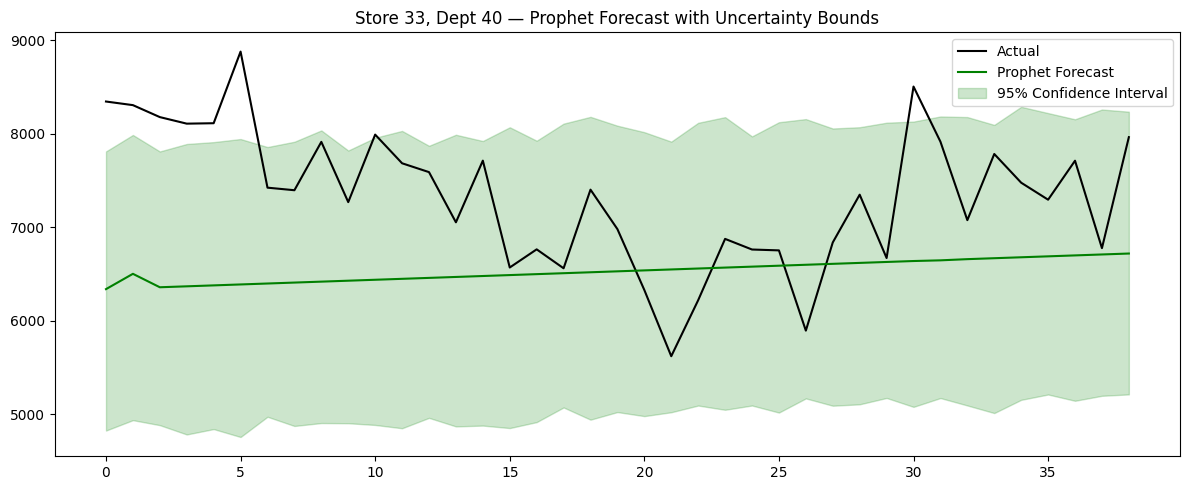

Actual values falling inside the 95% interval: 79.5% (ideally close to 95%)
SARIMA's calibration on the same series was: 84.6%


In [30]:
s, d = 33, 40
full_series = prophet_data[f"Store{s}_Dept{d}"]
train_series = full_series.iloc[:-39]
test_series = full_series.iloc[-39:]

model = Prophet(**best_prophet_config, interval_width=0.95)
model.fit(train_series)
future = model.make_future_dataframe(periods=39, freq='W-FRI')
forecast = model.predict(future)
forecast_tail = forecast.tail(39).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_series['y'].values, label='Actual', color='black')
ax.plot(forecast_tail['yhat'].values, label='Prophet Forecast', color='green')
ax.fill_between(range(39), forecast_tail['yhat_lower'], forecast_tail['yhat_upper'],
                 color='green', alpha=0.2, label='95% Confidence Interval')
ax.set_title(f"Store {s}, Dept {d} — Prophet Forecast with Uncertainty Bounds")
ax.legend()
plt.tight_layout()
plt.show()

actual = test_series['y'].values
in_interval = ((actual >= forecast_tail['yhat_lower'].values) & (actual <= forecast_tail['yhat_upper'].values)).mean()
print(f"Actual values falling inside the 95% interval: {in_interval:.1%} (ideally close to 95%)")
print(f"SARIMA's calibration on the same series was: 84.6%")

# Component Decomposition

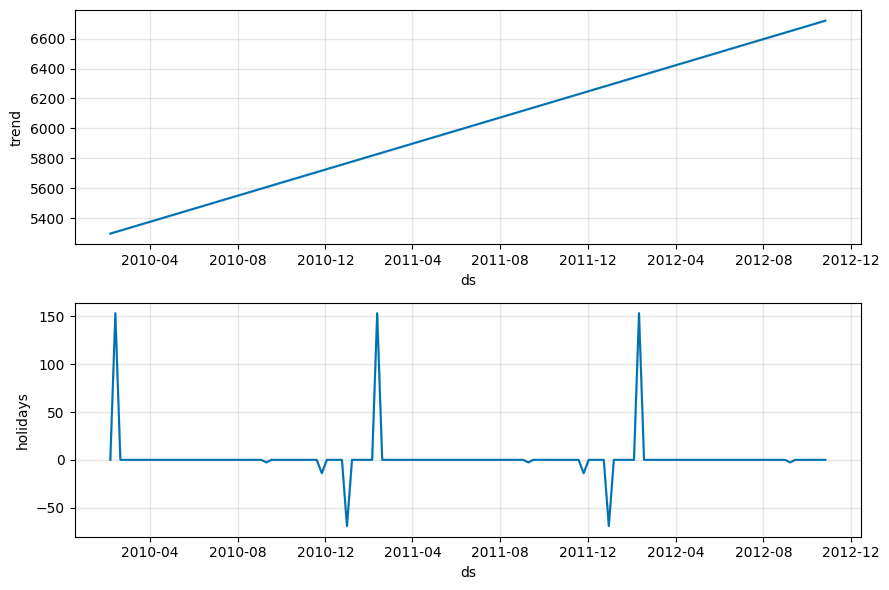

In [31]:
fig = model.plot_components(forecast)
plt.tight_layout()
plt.show()

# Final Model: Full History Retrain and Prediction

In [32]:
import time
start = time.time()

all_pairs_full = list(df_clean.groupby(['Store','Dept']).groups.keys())
prophet_final_results = []
failed_pairs = []

for i, (s, d) in enumerate(all_pairs_full):
    series = df_clean[(df_clean['Store']==s) & (df_clean['Dept']==d)].sort_values('Date')
    if len(series) < 52:
        failed_pairs.append((s, d))
        continue

    train_full = series[['Date','Weekly_Sales']].rename(columns={'Date':'ds','Weekly_Sales':'y'})
    dates_needed = df_test[(df_test['Store']==s) & (df_test['Dept']==d)]['Date'].sort_values()

    if len(dates_needed) == 0:
        continue

    try:
        model = Prophet(**best_prophet_config)
        model.fit(train_full)
        future = model.make_future_dataframe(periods=len(dates_needed), freq='W-FRI')
        forecast = model.predict(future)
        pred = forecast[['ds','yhat']].tail(len(dates_needed))

        for dt, val in zip(dates_needed, pred['yhat'].values):
            prophet_final_results.append({'Store': s, 'Dept': d, 'Date': dt, 'Weekly_Sales': val})
    except Exception:
        failed_pairs.append((s, d))
        continue

elapsed = time.time() - start
print(f"Total time: {elapsed/60:.1f} minutes")
print(f"Series succeeded: {len(all_pairs_full) - len(failed_pairs)} / {len(all_pairs_full)}")
print(f"Series failed/skipped: {len(failed_pairs)}")

prophet_final_df = pd.DataFrame(prophet_final_results)
print(prophet_final_df.shape)

00:02:26 - cmdstanpy - INFO - Chain [1] start processing
00:02:26 - cmdstanpy - INFO - Chain [1] done processing
00:02:27 - cmdstanpy - INFO - Chain [1] start processing
00:02:27 - cmdstanpy - INFO - Chain [1] done processing
00:02:27 - cmdstanpy - INFO - Chain [1] start processing
00:02:27 - cmdstanpy - INFO - Chain [1] done processing
00:02:27 - cmdstanpy - INFO - Chain [1] start processing
00:02:27 - cmdstanpy - INFO - Chain [1] done processing
00:02:27 - cmdstanpy - INFO - Chain [1] start processing
00:02:27 - cmdstanpy - INFO - Chain [1] done processing
00:02:27 - cmdstanpy - INFO - Chain [1] start processing
00:02:27 - cmdstanpy - INFO - Chain [1] done processing
00:02:27 - cmdstanpy - INFO - Chain [1] start processing
00:02:27 - cmdstanpy - INFO - Chain [1] done processing
00:02:27 - cmdstanpy - INFO - Chain [1] start processing
00:02:27 - cmdstanpy - INFO - Chain [1] done processing
00:02:28 - cmdstanpy - INFO - Chain [1] start processing
00:02:28 - cmdstanpy - INFO - Chain [1]

Total time: 7.3 minutes
Series succeeded: 2991 / 3331
Series failed/skipped: 340
(113105, 4)


In [34]:
def fallback_for_missing(df_train, missing_test_rows):
    recent = df_train[df_train['Date'] >= df_train['Date'].max() - pd.Timedelta(weeks=52)]
    med = recent.groupby(['Type', 'Dept'])['Weekly_Sales'].median()
    out = missing_test_rows.copy()
    out['Weekly_Sales'] = [med.get((t, d), 0.0) for t, d in zip(out['Type'], out['Dept'])]
    out['Weekly_Sales'] = out['Weekly_Sales'].clip(lower=0)
    return out

covered_ids = set(zip(prophet_final_df.Store, prophet_final_df.Dept, prophet_final_df.Date))
df_test_check = df_test.copy()
df_test_check['covered'] = df_test_check.apply(lambda r: (r['Store'], r['Dept'], r['Date']) in covered_ids, axis=1)
missing_rows = df_test_check[~df_test_check['covered']].drop(columns=['covered'])
print("Genuinely missing rows to fill:", len(missing_rows))

fallback_result = fallback_for_missing(df_clean, missing_rows)
fallback_result = fallback_result[['Store','Dept','Date','Weekly_Sales']]

final_predictions_prophet = pd.concat([prophet_final_df, fallback_result], ignore_index=True)
final_predictions_prophet['Weekly_Sales'] = final_predictions_prophet['Weekly_Sales'].clip(lower=0)
final_predictions_prophet['Id'] = (final_predictions_prophet['Store'].astype(str) + '_' +
                                     final_predictions_prophet['Dept'].astype(str) + '_' +
                                     final_predictions_prophet['Date'].dt.strftime('%Y-%m-%d'))

submission_prophet = final_predictions_prophet[['Id','Weekly_Sales']].sort_values('Id').reset_index(drop=True)
submission_prophet = submission_prophet.drop_duplicates(subset='Id', keep='first')
assert len(submission_prophet) == len(test), f"Row mismatch: {len(submission_prophet)} vs {len(test)}"

submission_prophet.to_csv('submission_prophet.csv', index=False)
print(submission_prophet.shape)

Genuinely missing rows to fill: 1959
(115064, 2)


# Pipeline Artifact (with reload verification from the start)

In [35]:
class ProphetPipeline(mlflow.pyfunc.PythonModel):
    def __init__(self, train_clean, config):
        self.train_clean = train_clean
        self.config = config

    def predict(self, context, model_input):
        test_merged = load_and_merge(model_input.copy(), features, stores)
        test_clean = preprocess(test_merged)

        all_pairs = list(self.train_clean.groupby(['Store','Dept']).groups.keys())
        results = []
        covered = set()

        for (s, d) in all_pairs:
            series = self.train_clean[(self.train_clean['Store']==s) & (self.train_clean['Dept']==d)].sort_values('Date')
            if len(series) < 52:
                continue
            dates_needed = test_clean[(test_clean['Store']==s) & (test_clean['Dept']==d)]['Date'].sort_values()
            if len(dates_needed) == 0:
                continue
            try:
                train_full = series[['Date','Weekly_Sales']].rename(columns={'Date':'ds','Weekly_Sales':'y'})
                model = Prophet(**self.config)
                model.fit(train_full)
                future = model.make_future_dataframe(periods=len(dates_needed), freq='W-FRI')
                forecast = model.predict(future)
                pred = forecast[['ds','yhat']].tail(len(dates_needed))
                for dt, val in zip(dates_needed, pred['yhat'].values):
                    results.append({'Store': s, 'Dept': d, 'Date': dt, 'Weekly_Sales': val})
                    covered.add((s, d, dt))
            except Exception:
                continue

        pred_df = pd.DataFrame(results) if results else pd.DataFrame(columns=['Store','Dept','Date','Weekly_Sales'])

        missing = test_clean[~test_clean.apply(lambda r: (r['Store'], r['Dept'], r['Date']) in covered, axis=1)]
        recent = self.train_clean[self.train_clean['Date'] >= self.train_clean['Date'].max() - pd.Timedelta(weeks=52)]
        med = recent.groupby(['Type','Dept'])['Weekly_Sales'].median()
        missing = missing.copy()
        missing['Weekly_Sales'] = [med.get((t,d2), 0.0) for t,d2 in zip(missing['Type'], missing['Dept'])]

        final = pd.concat([pred_df, missing[['Store','Dept','Date','Weekly_Sales']]], ignore_index=True)
        final['Weekly_Sales'] = final['Weekly_Sales'].clip(lower=0)
        return final

/usr/local/lib/python3.12/dist-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [36]:
pipeline_prophet = ProphetPipeline(train_clean=df_clean, config=best_prophet_config)

demo_test_prophet = test[test.apply(lambda r: (r['Store'], r['Dept']) in set(examples), axis=1)].copy()
demo_result_prophet = pipeline_prophet.predict(None, demo_test_prophet)
print(demo_result_prophet.shape)
print(demo_result_prophet.head())

00:13:10 - cmdstanpy - INFO - Chain [1] start processing
00:13:10 - cmdstanpy - INFO - Chain [1] done processing
00:13:11 - cmdstanpy - INFO - Chain [1] start processing
00:13:11 - cmdstanpy - INFO - Chain [1] done processing
00:13:12 - cmdstanpy - INFO - Chain [1] start processing
00:13:12 - cmdstanpy - INFO - Chain [1] done processing
00:13:14 - cmdstanpy - INFO - Chain [1] start processing
00:13:14 - cmdstanpy - INFO - Chain [1] done processing
00:13:17 - cmdstanpy - INFO - Chain [1] start processing
00:13:17 - cmdstanpy - INFO - Chain [1] done processing


(195, 4)
   Store  Dept       Date  Weekly_Sales
0      1     1 2012-11-02  33393.923675
1      1     1 2012-11-09  27633.214816
2      1     1 2012-11-16  19377.881443
3      1     1 2012-11-23  16284.413454
4      1     1 2012-11-30  22474.210311


In [37]:
with mlflow.start_run(run_name="Prophet_Pipeline_Wrapped"):
    mlflow.log_params(best_prophet_config)
    mlflow.log_param("scope", "full dataset, all series with >=52 weeks history")
    model_info = mlflow.pyfunc.log_model(python_model=pipeline_prophet, name="pipeline")

loaded_model = mlflow.pyfunc.load_model(model_info.model_uri)
reloaded_preds = loaded_model.predict(test)

reloaded_preds['Id'] = (reloaded_preds['Store'].astype(str) + '_' +
                          reloaded_preds['Dept'].astype(str) + '_' +
                          reloaded_preds['Date'].dt.strftime('%Y-%m-%d'))
reloaded_submission = reloaded_preds[['Id','Weekly_Sales']].sort_values('Id').reset_index(drop=True)
reloaded_submission = reloaded_submission.drop_duplicates(subset='Id', keep='first')

old_submission = pd.read_csv('submission_prophet.csv')
comparison = reloaded_submission.merge(old_submission, on='Id', suffixes=('_reloaded','_original'))
max_diff = (comparison['Weekly_Sales_reloaded'] - comparison['Weekly_Sales_original']).abs().max()

print("Rows compared:", len(comparison), "/", len(old_submission))
print("Max diff (reloaded model vs original submission):", max_diff)

2026/07/12 00:13:25 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


🏃 View run Prophet_Pipeline_Wrapped at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8/runs/e0c9a3765166453aa88ffe4c9b6381cb
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/8


00:14:09 - cmdstanpy - INFO - Chain [1] start processing
00:14:09 - cmdstanpy - INFO - Chain [1] done processing
00:14:09 - cmdstanpy - INFO - Chain [1] start processing
00:14:09 - cmdstanpy - INFO - Chain [1] done processing
00:14:09 - cmdstanpy - INFO - Chain [1] start processing
00:14:09 - cmdstanpy - INFO - Chain [1] done processing
00:14:09 - cmdstanpy - INFO - Chain [1] start processing
00:14:09 - cmdstanpy - INFO - Chain [1] done processing
00:14:09 - cmdstanpy - INFO - Chain [1] start processing
00:14:09 - cmdstanpy - INFO - Chain [1] done processing
00:14:09 - cmdstanpy - INFO - Chain [1] start processing
00:14:09 - cmdstanpy - INFO - Chain [1] done processing
00:14:10 - cmdstanpy - INFO - Chain [1] start processing
00:14:10 - cmdstanpy - INFO - Chain [1] done processing
00:14:10 - cmdstanpy - INFO - Chain [1] start processing
00:14:10 - cmdstanpy - INFO - Chain [1] done processing
00:14:10 - cmdstanpy - INFO - Chain [1] start processing
00:14:10 - cmdstanpy - INFO - Chain [1]

Rows compared: 115064 / 115064
Max diff (reloaded model vs original submission): 5.820766091346741e-11
